<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Compare technologies

In [3]:
dataset_name = "smartseq_10x"  # options: parse_10x, smartseq_10x
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [ ]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

adata_10x_url, adata_parse_url, adata_smartseq_url = None, None, None
adata_path_raw_10x, adata_path_raw_parse, adata_path_raw_smartseq = None, None, None

adata_path_raw_smartseq = os.path.join(data_dir, "adata_smartseq_raw.h5ad")

technology_to_adata_raw, technology_to_adata_raw_path = {}, {}
if dataset_name == "parse_10x":
    technologies = ["10x", "parse"]
    
    adata_10x_url = "https://caltech.box.com/shared/static/g03q46wpr5uj81gqp0dh3dyy02zw200e.h5ad"
    adata_parse_url = "https://caltech.box.com/shared/static/4bai2qfe7xk2956ug1t7bpdw0q6tspie.h5ad"

    adata_path_raw_10x = os.path.join(data_dir, "adata_10x_raw.h5ad")
    adata_path_raw_parse = os.path.join(data_dir, "adata_parse_raw.h5ad")

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}

    if not os.path.exists(adata_path_raw_parse):
        !wget -O {adata_path_raw_parse} {adata_parse_url}

    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["parse"] = adata_path_raw_parse

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["parse"] = ad.read_h5ad(adata_path_raw_parse)

    technology_to_umi_cutoff = {
        "10x": 300,
        "parse": 200,
    }
    technology_to_leiden_resolution = {
        "10x": 2.0,
        "parse": 2.5
    }

elif dataset_name == "smartseq_10x":
    technologies = ["10x", "smartseq"]
    
    adata_10x_url = "https://caltech.box.com/shared/static/i9ot39o8jzp9kbg36rx1wv8ggsp9cq87.h5ad"  # "https://data.nemoarchive.org/biccn/lab/zeng/transcriptome/scell/10x_v3/mouse/processed/MOp/CellRanger5/L8TX_190430_01_H08.mex.tar.gz"
    adata_smartseq_url = "https://caltech.box.com/shared/static/blbax8btlgc94ahb6whot17ckxz37csz.h5ad"  # "https://data.nemoarchive.org/biccn/grant/u19_zeng/zeng/transcriptome/scell/SSv4/mouse/processed/analysis/SMARTer_cells_MOp/exon.counts.csv.gz"

    adata_path_raw_10x = os.path.join(data_dir, "L8TX_190430_01_H08")
    adata_path_raw_smartseq = os.path.join(data_dir, "exon.counts.csv.gz")

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["smartseq"] = ad.read_h5ad(adata_path_raw_smartseq)

    # if not os.path.exists(adata_path_raw_10x):
    #     !wget -O {adata_path_raw_10x}.mex.tar.gz {adata_10x_url}
    #     !tar -xvzf {adata_path_raw_10x}.mex.tar.gz -C {data_dir}
    
    # if not os.path.exists(adata_path_raw_smartseq):
    #     !wget -O {adata_path_raw_smartseq} {adata_smartseq_url}
    
    # technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    # technology_to_adata_raw_path["smartseq"] = adata_path_raw_smartseq

    # technology_to_adata_raw["10x"] = cs_utils.load_adata(adata_path_raw_10x)

    # df_smartseq = pd.read_csv("exon.counts.csv.gz", index_col=0, compression='gzip')
    # technology_to_adata_raw["smartseq"] = ad.AnnData(
    #     X=sp.csr_matrix(df_smartseq.values.T),
    #     obs=pd.DataFrame(index=df_smartseq.columns),
    #     var=pd.DataFrame(index=df_smartseq.index),
    # )

    technology_to_umi_cutoff = {
        "10x": None,
        "smartseq": None,
    }
    technology_to_leiden_resolution = {
        "10x": 1.0,
        "smartseq": 1.0
    }
else:
    raise ValueError(f"dataset_name {dataset_name} not recognized.")

technology0, technology1 = technologies[0], technologies[1]

--2026-01-16 13:02:55--  https://data.nemoarchive.org/biccn/grant/u19_zeng/zeng/transcriptome/scell/SSv4/mouse/processed/analysis/SMARTer_cells_MOp/exon.counts.csv.gz
Resolving data.nemoarchive.org (data.nemoarchive.org)... 134.192.156.26
Connecting to data.nemoarchive.org (data.nemoarchive.org)|134.192.156.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91379805 (87M) [application/x-gzip]
Saving to: ‘/home/jrich/Desktop/cellsweep/notebooks/data/smartseq_10x/exon.counts.csv.gz’

/home/jrich/Desktop 100%[===================>]  87.15M  89.7KB/s    in 14m 4s  

2026-01-16 13:16:59 (106 KB/s) - ‘/home/jrich/Desktop/cellsweep/notebooks/data/smartseq_10x/exon.counts.csv.gz’ saved [91379805/91379805]



FileNotFoundError: No valid 10x dataset found under '/home/jrich/Desktop/cellsweep/notebooks/data/smartseq_10x/L8TX_190430_01_H08'. Expected matrix.mtx, barcodes.tsv, and genes.tsv or features.tsv.

## Knee plot - use this output to estimate umi_cutoff

Processing technology: 10x
Processing technology: parse


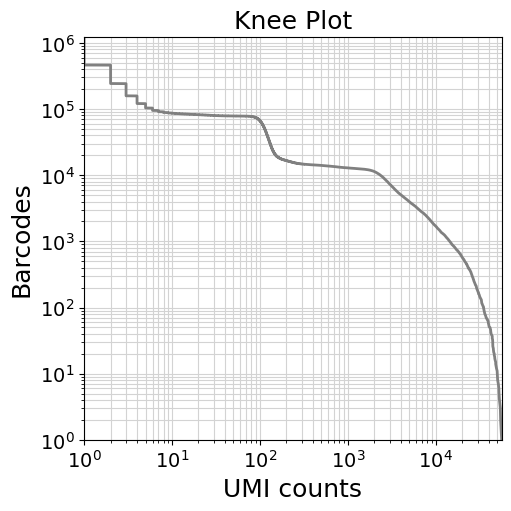

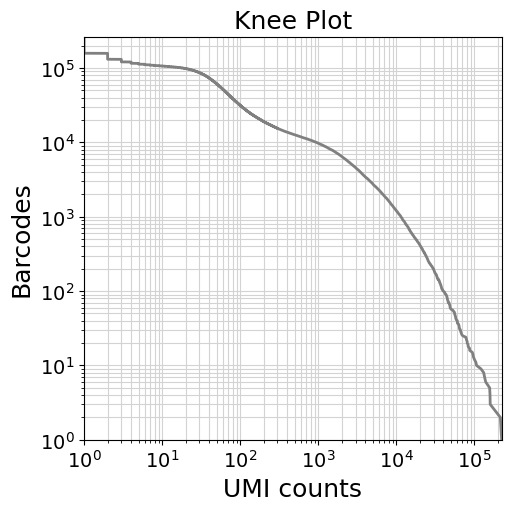

In [ ]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Processing technology: {technology}")
    _ = cs_utils.knee_plot(adata_raw, transpose=True, out_path=os.path.join(out_dir, f"knee_plot_{technology}.png"))

In [ ]:
# technology_to_umi_cutoff = {}   #!!! update

In [ ]:
for technology, adata_raw in technology_to_adata_raw.items():
    if technology == "smartseq":
        print(f"Skipping empty droplet inference for technology: {technology} (each barcode is a cell)")
        continue

    print(f"Inferring empty droplets for technology: {technology}")
    #$ (1) UMI threshold
    # umi_cutoff = technology_to_umi_cutoff[technology]
    # adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]

    #$ (2) EmptyDrops
    parent_dir = technology_to_adata_raw_path[technology].replace(".h5ad", "_raw_dir")
    paths = cs_utils.write_10x_like(adata_raw, parent_dir, gzip_output=True, is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=False)
    raw_tar_file_dir = paths["raw"]

    emptydrops_barcodes_file = os.path.join(data_dir, f"emptydrops_barcodes_{technology}.txt")
    if not os.path.exists(emptydrops_barcodes_file) or overwrite:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_emptydrops.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {emptydrops_barcodes_file.replace(cellsweep_dir, rver_docker_workspace)}

    with open(emptydrops_barcodes_file) as f:
        emptydrops_cellular_barcodes = set(line.strip() for line in f)

    adata_raw.obs["is_empty"] = ~adata_raw.obs.index.isin(emptydrops_cellular_barcodes)

    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    technology_to_adata_raw[technology] = adata_raw

Inferring empty droplets for technology: 10x
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/parse_10x/adata_10x_raw_raw_dir/raw_gene_bc_matrices/genome'. Skipping write.
Inferring empty droplets for technology: parse
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/parse_10x/adata_parse_raw_raw_dir/raw_gene_bc_matrices/genome'. Skipping write.


## cellsweep

In [ ]:
technology_to_adata_cellsweep, technology_to_adata_cellsweep_empty_barcodes = {}, {}
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Denoising counts for technology: {technology}")
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{technology}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{technology}.log")
    freeze_ambient_profile = True if technology != "smartseq" else False
    
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            leiden_resolution = technology_to_leiden_resolution[technology]
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha = 0.9, beta = 0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=freeze_ambient_profile, max_iter=1500, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        print(f"Loading existing cellsweep denoised data for technology: {technology}")
        adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
    
    adata_cellsweep_empty_barcodes = adata_cellsweep[adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep_empty_barcodes.var_names_make_unique()
    technology_to_adata_cellsweep_empty_barcodes[technology] = adata_cellsweep_empty_barcodes

    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    
    technology_to_adata_cellsweep[technology] = adata_cellsweep

Denoising counts for technology: 10x


11:15:46 - INFO - Adata initial shape: (16532, 34183)
11:15:46 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
11:15:46 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
11:15:46 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like cl

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/parse_10x/cellsweep_10x.log


11:16:21 - DEBUG - Number of parameters in the cellsweep model: 700,193 (alpha: 16,532, beta: 1, p_k: 683,660)
11:16:21 - INFO - Inferring the gene ambient profile from empty droplets.
11:16:21 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
11:16:21 - INFO - Performing Sparse EM with 32 Numba thread(s)
11:16:27 - INFO - EM Iter   1: ll=-537.819 log_delta_p=inf min_alpha=0.1053 mean_alpha=0.8689 median_alpha=0.8687 max_alpha=0.9000 beta=0.103207
11:16:27 - DEBUG - 1366 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:16:30 - INFO - EM Iter   2: ll=-536.113 log_delta_p=inf min_alpha=0.0066 mean_alpha=0.8167 median_alpha=0.8173 max_alpha=0.9000 beta=0.104752
11:16:30 - DEBUG - 965 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:16:31 - INFO - EM Iter   3: ll=-534.375 log_delta_p=-1.3962 min_alpha=0.0007

Denoising counts for technology: parse


11:18:03 - INFO - Adata initial shape: (6978, 34183)
11:18:03 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
11:18:03 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
11:18:03 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clu

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/parse_10x/cellsweep_parse.log


11:18:05 - DEBUG - Number of parameters in the cellsweep model: 1,066,652 (alpha: 6,978, beta: 1, p_k: 1,059,673)
11:18:05 - INFO - Inferring the gene ambient profile from empty droplets.
11:18:05 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
11:18:05 - INFO - Performing Sparse EM with 32 Numba thread(s)
11:18:05 - INFO - EM Iter   1: ll=-1930.056 log_delta_p=inf min_alpha=0.6979 mean_alpha=0.8840 median_alpha=0.8891 max_alpha=0.9000 beta=0.100478
11:18:05 - DEBUG - 53 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:18:06 - INFO - EM Iter   2: ll=-1932.457 log_delta_p=inf min_alpha=0.4918 mean_alpha=0.8587 median_alpha=0.8718 max_alpha=0.9000 beta=0.102581
11:18:06 - DEBUG - 39 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:18:06 - INFO - EM Iter   3: ll=-1930.138 log_delta_p=-1.2208 min_alpha=0.3

## Analysis

### Raw vs cellsweep knee plot, scatterplots

Technology: 10x


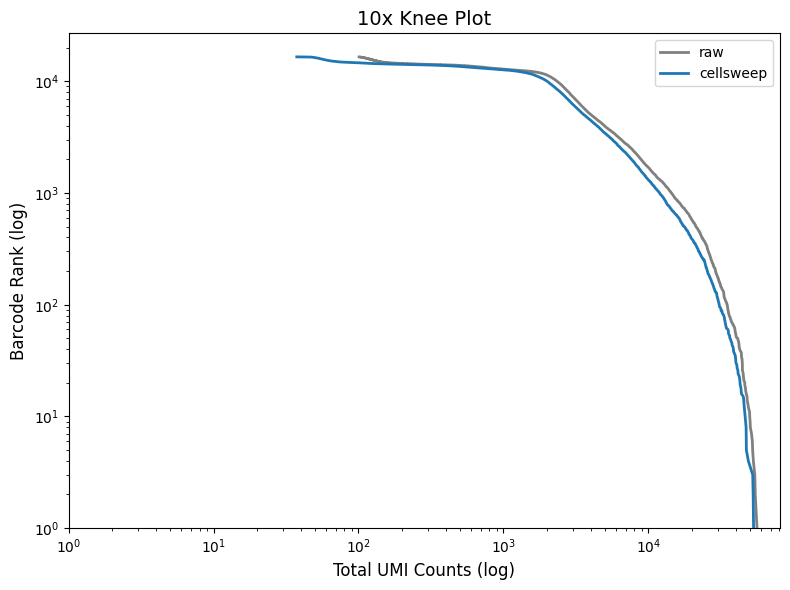

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


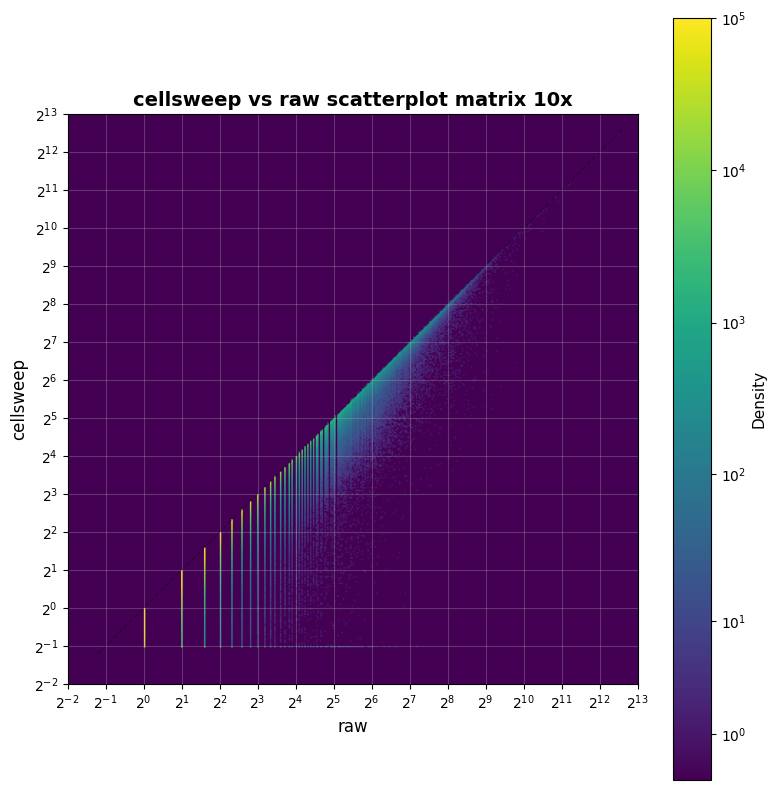

Creating scatterplot...
Calculating scatterplot...


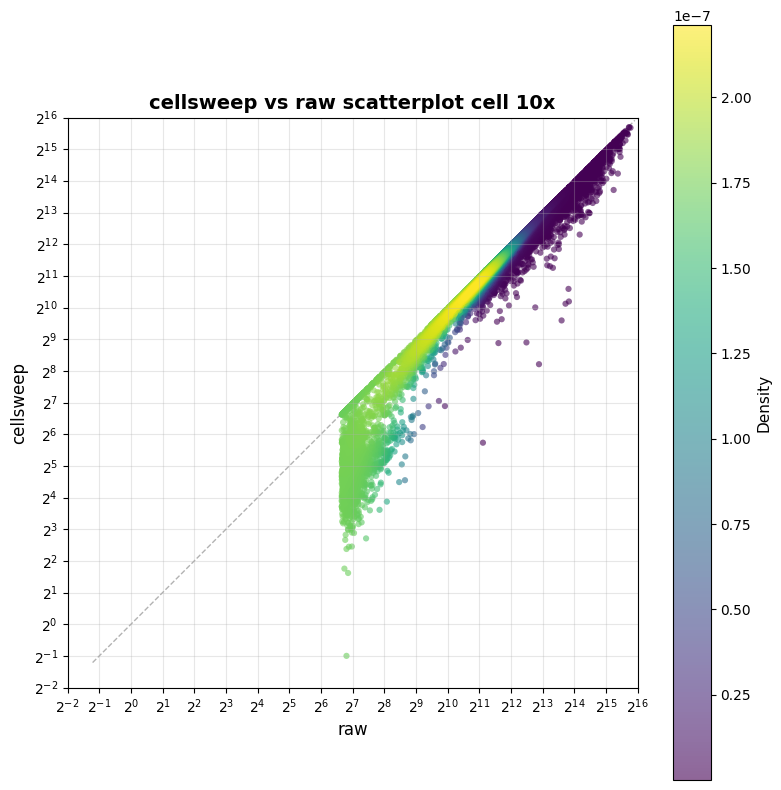

Creating scatterplot...
Calculating scatterplot...


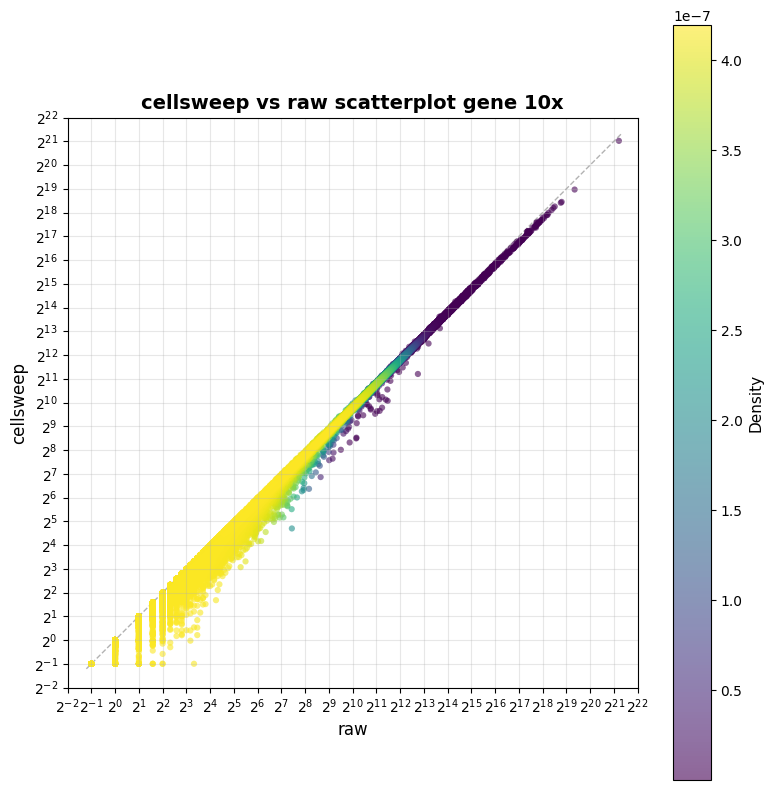

Technology: parse


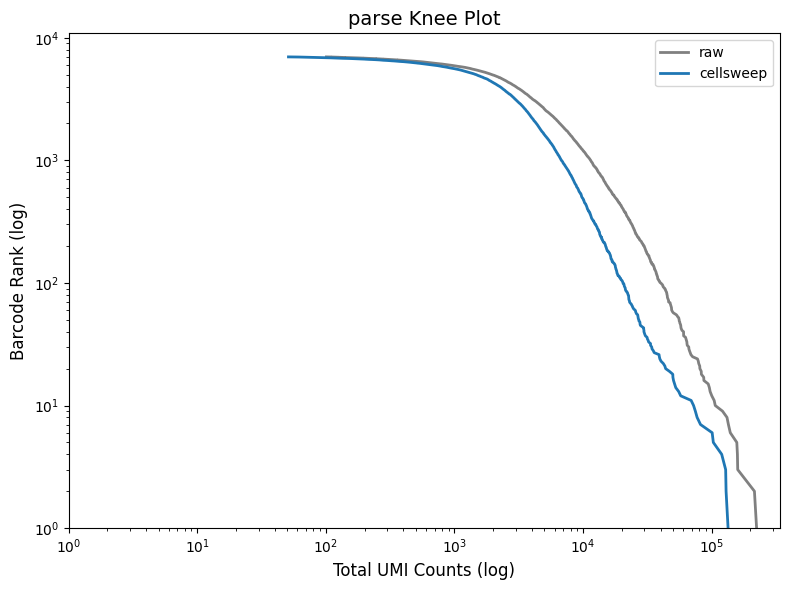

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


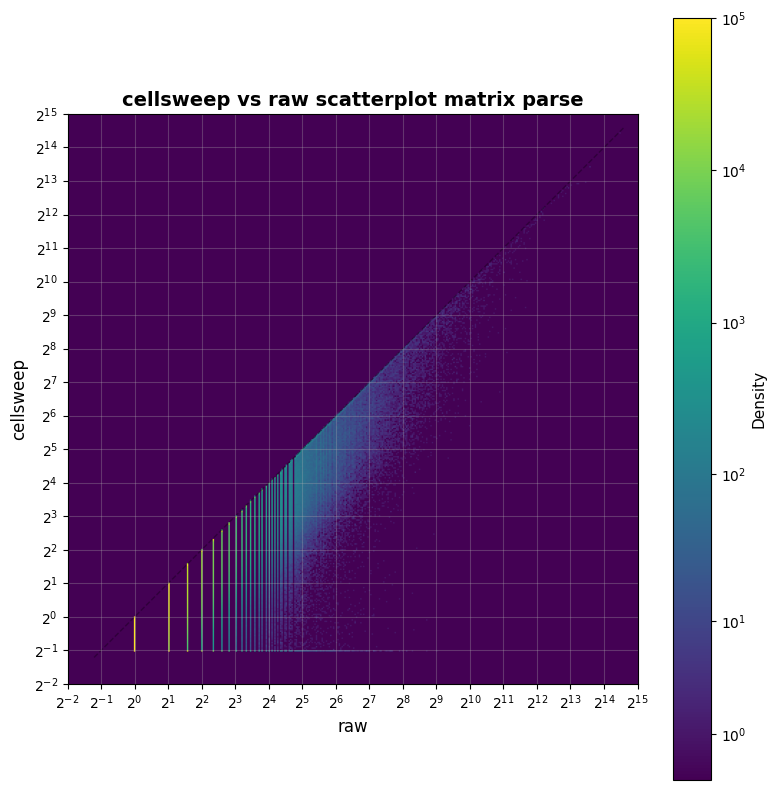

Creating scatterplot...
Calculating scatterplot...


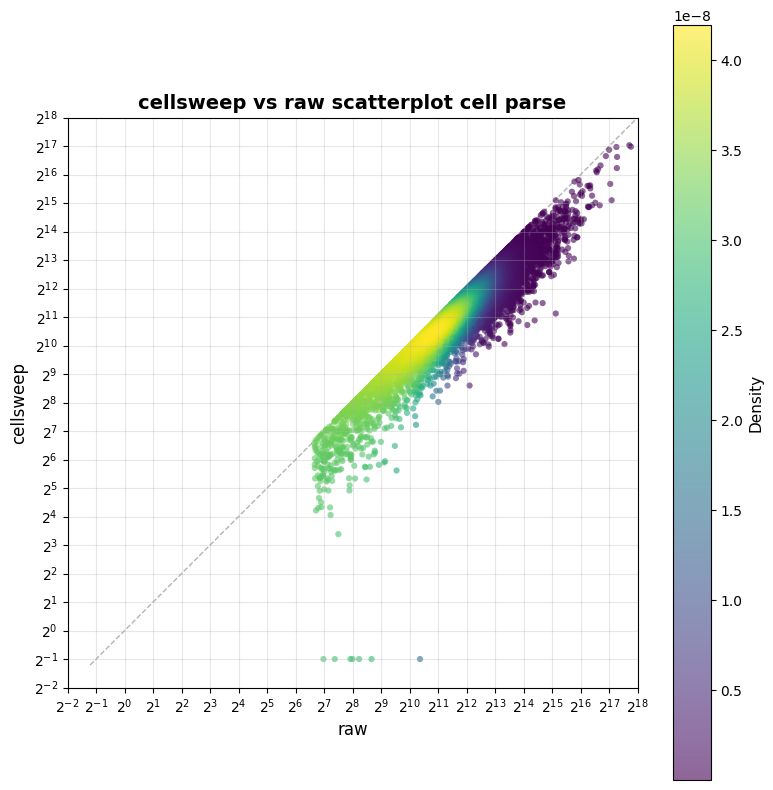

Creating scatterplot...
Calculating scatterplot...


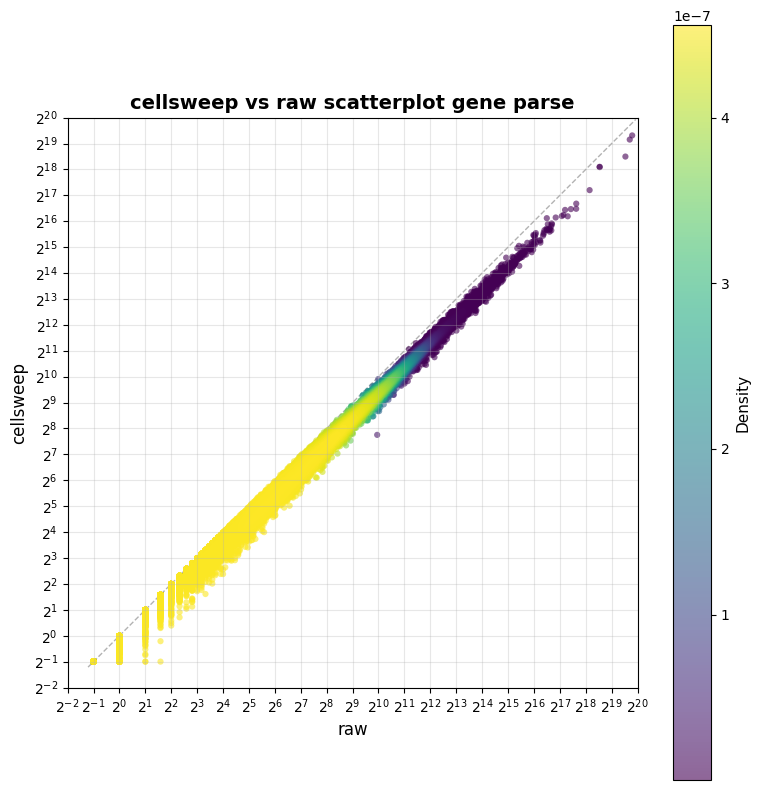

In [ ]:
for technology in technologies:
    print(f"Technology: {technology}")
    adata_raw = technology_to_adata_raw[technology]
    adata_cellsweep = technology_to_adata_cellsweep[technology]
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title=f"{technology} Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{technology}_knee_plot.png"))

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot matrix {technology}", out_path=os.path.join(out_dir, f"{technology}_matrix_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot cell {technology}", out_path=os.path.join(out_dir, f"{technology}_cell_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot gene {technology}", out_path=os.path.join(out_dir, f"{technology}_gene_expression_scatterplot.png"), show=True)

### Ambient hat per gene scatterplot across technologies

Creating scatterplot...
Calculating scatterplot...


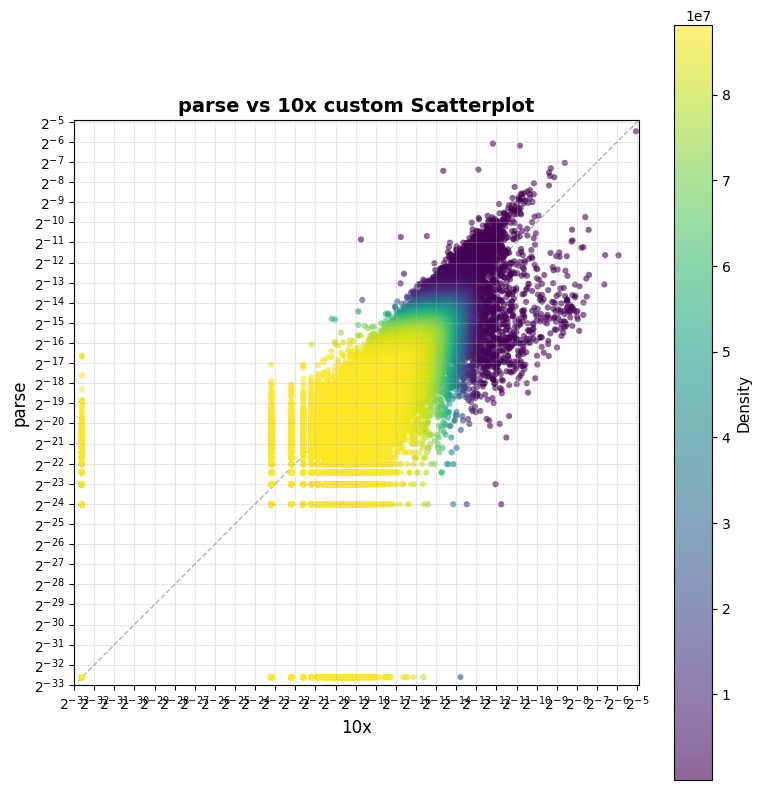

In [ ]:
s = technology_to_adata_cellsweep[technology0].var["ambient_hat"]
nonzero_min = s[s > 0].min()
cs_utils.plot_matrix_scatterplot(technology_to_adata_cellsweep[technology0].var["ambient_hat"], technology_to_adata_cellsweep[technology1].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=technology0, y_axis=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_ambient_hat_scatterplot.png"), show=True)

### Ambient fraction per cell histogram across technologies

10x cell contamination AUC: 164.7457155229289
parse cell contamination AUC: 69.77999999999999


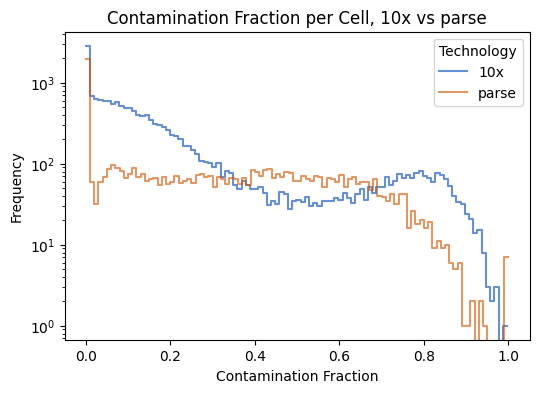

In [ ]:
cs_utils.plot_multi_histogram(technology_to_adata_cellsweep[technology0].obs, technology_to_adata_cellsweep[technology1].obs, plotting_column="alpha_hat", df1_name=technology0, df2_name=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_cell_empty_fraction_scatterplot.png"), show=True)

### Adata var ambient hat PMF comparison

Creating scatterplot...
Calculating scatterplot...


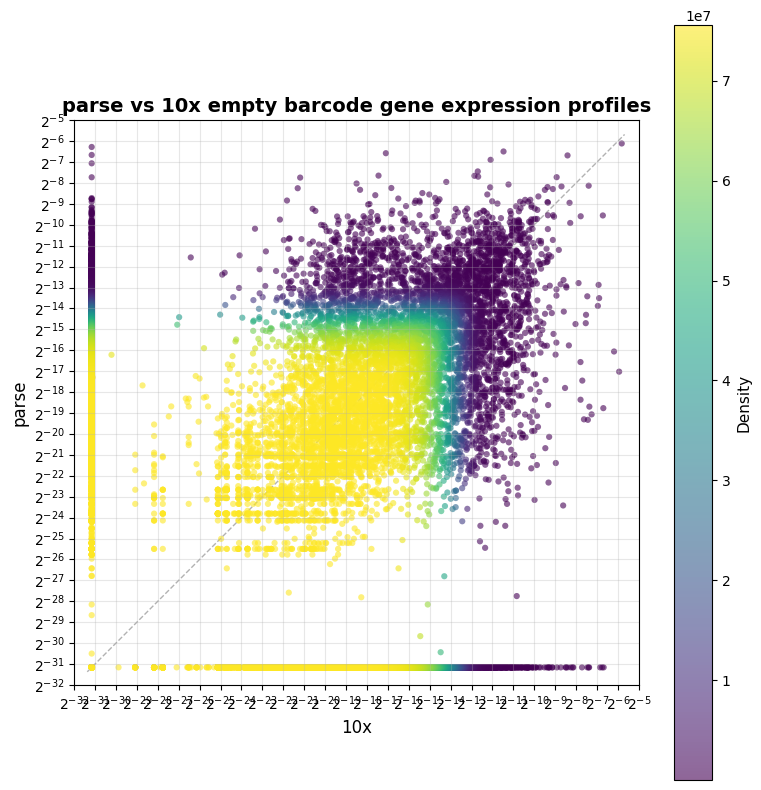

In [ ]:
def add_fraction_total_counts(adata):
    if "fraction_total_counts" in adata.var.columns:
        print("fraction_total_counts already present in adata.var, skipping computation.")
        return adata

    X = adata.X

    # Sum per gene (columns)
    if sp.issparse(X):
        gene_sums = np.asarray(X.sum(axis=0)).ravel()
        total_counts = X.sum()
    else:
        gene_sums = X.sum(axis=0)
        total_counts = X.sum()

    # Fraction of total counts per gene
    adata.var["fraction_total_counts"] = gene_sums / total_counts
    return adata

technology_to_adata_cellsweep_empty_barcodes[technology0] = add_fraction_total_counts(technology_to_adata_cellsweep_empty_barcodes[technology0])
technology_to_adata_cellsweep_empty_barcodes[technology1] = add_fraction_total_counts(technology_to_adata_cellsweep_empty_barcodes[technology1])

s = technology_to_adata_cellsweep_empty_barcodes[technology0].var["fraction_total_counts"]
nonzero_min = s[s > 0].min()
cs_utils.plot_matrix_scatterplot(technology_to_adata_cellsweep_empty_barcodes[technology0].var["fraction_total_counts"], technology_to_adata_cellsweep_empty_barcodes[technology1].var["fraction_total_counts"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=technology0, y_axis=technology1, title="parse vs 10x empty barcode gene expression profiles", out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_fraction_total_counts_scatterplot_empty_barcodes.png"), show=True)